In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [111]:
df_main = pd.read_csv(r'kidney_disease_dataset.csv')

In [112]:
df_main['Target'] = df_main['Target'].replace({
    'Low_Risk':'Disease',
    'Severe_Disease': 'Disease',
    'High_Risk': 'Disease',
    'Moderate_Risk': 'Disease'
})

In [113]:
df_main['Target'].value_counts()

,count
Target,
No_Disease,16432
Disease,4106


In [114]:
object_columns = [
    'Red blood cells in urine','Pus cells in urine','Pus cell clumps in urine','Bacteria in urine','Hypertension (yes/no)',
    'Diabetes mellitus (yes/no)','Coronary artery disease (yes/no)','Appetite (good/poor)','Pedal edema (yes/no)','Anemia (yes/no)',
    'Family history of chronic kidney disease','Smoking status','Physical activity level','Urinary sediment microscopy results'
]

from sklearn.preprocessing import LabelEncoder
def label_encode_object_columns(df_main,save_path='label_encoders'):
    df_encoded = df_main.copy()
    label_encoders = {}



    for col in object_columns:
        LE = LabelEncoder()
        df_encoded[col] = LE.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = LE



    return df_encoded, label_encoders
df_encoded,label_encoder  = label_encode_object_columns(df_main)

In [115]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist



disease_df = df_encoded[df_encoded['Target'] == 'Disease']
no_disease_df = df_encoded[df_encoded['Target'] == 'No_Disease']
features = df_encoded.columns.drop('Target')


scaler = StandardScaler()
disease_scaled = scaler.fit_transform(disease_df[features])
no_disease_scaled = scaler.transform(no_disease_df[features])

disease_mean = np.mean(disease_scaled, axis=0)


dist_to_disease = cdist(no_disease_scaled, [disease_mean], metric='euclidean').flatten()


top_indices = np.argsort(dist_to_disease)[-5894:]
no_disease_subset = no_disease_df.iloc[top_indices]

print("Selected rows:", no_disease_subset.shape[0])


Selected rows: 5894


In [116]:

df_merged = pd.concat([disease_df, no_disease_subset], ignore_index=True)


df_merged = df_merged.sample(frac=1, random_state=42).reset_index(drop=True)


print("Merged dataset shape:", df_merged.shape)
print("Target distribution:\n", df_merged['Target'].value_counts())


Merged dataset shape: (10000, 43)
Target distribution:
 Target
No_Disease    5894
Disease       4106
Name: count, dtype: int64


In [117]:
df_merged.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,26,85,1.024,4,2,1,0,0,0,482,...,0,26.7,0,3,11,1.94,1,1.53,3.64,No_Disease
1,36,126,1.017,3,5,0,0,0,0,71,...,0,30.0,1,1,26,1.94,1,9.01,7.76,No_Disease
2,14,125,1.022,4,1,0,0,0,0,147,...,0,29.2,0,16,2,2.13,0,3.95,7.14,Disease
3,34,126,1.019,5,2,0,1,1,0,498,...,0,30.4,1,28,2,1.10,1,7.81,1.93,No_Disease
4,34,90,1.020,1,0,1,1,1,0,214,...,0,16.0,0,26,26,2.41,0,8.31,13.47,No_Disease


In [118]:
df_merged.describe()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Family history of chronic kidney disease,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,47.596200,130.595900,1.015044,2.511100,2.503800,0.498100,0.493600,0.502800,0.498600,284.853900,...,0.491100,0.496300,27.554610,0.992200,15.005200,14.894000,1.745257,0.498000,5.060412,7.699283
std,26.265607,30.604141,0.006100,1.771945,1.779692,0.500021,0.499984,0.500017,0.500023,130.546266,...,0.499946,0.500011,7.627547,0.840482,9.392976,9.392997,0.756262,0.500021,2.998062,4.379237
min,5.000000,80.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,...,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.100000,0.500000
25%,24.000000,103.000000,1.010000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,165.000000,...,0.000000,0.000000,20.600000,0.000000,7.000000,6.000000,1.060000,0.000000,2.320000,3.760000
50%,48.000000,131.000000,1.015000,3.000000,3.000000,0.000000,0.000000,1.000000,0.000000,284.000000,...,0.000000,0.000000,27.600000,1.000000,15.000000,15.000000,1.740000,0.000000,5.110000,7.730000
75%,71.000000,158.000000,1.021000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,402.000000,...,1.000000,1.000000,34.600000,2.000000,23.000000,23.000000,2.430000,1.000000,7.770000,11.572500
max,90.000000,180.000000,1.025000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,500.000000,...,1.000000,1.000000,40.000000,2.000000,30.000000,30.000000,3.000000,1.000000,10.000000,15.000000


In [119]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           10000 non-null  int64  
 1   Blood pressure (mm/Hg)                       10000 non-null  int64  
 2   Specific gravity of urine                    10000 non-null  float64
 3   Albumin in urine                             10000 non-null  int64  
 4   Sugar in urine                               10000 non-null  int64  
 5   Red blood cells in urine                     10000 non-null  int64  
 6   Pus cells in urine                           10000 non-null  int64  
 7   Pus cell clumps in urine                     10000 non-null  int64  
 8   Bacteria in urine                            10000 non-null  int64  
 9   Random blood glucose level (mg/dl)           10000 non-null  int64  
 10 

In [120]:
target_mapping = {'No_Disease':0,
                  'Disease':1}
df_merged['Target'] = df_merged['Target'].map(target_mapping)

In [121]:
!pip install catboost


Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.82      0.79      1179
           1       0.71      0.65      0.68       821

    accuracy                           0.75      2000
   macro avg       0.74      0.73      0.74      2000
weighted avg       0.75      0.75      0.75      2000



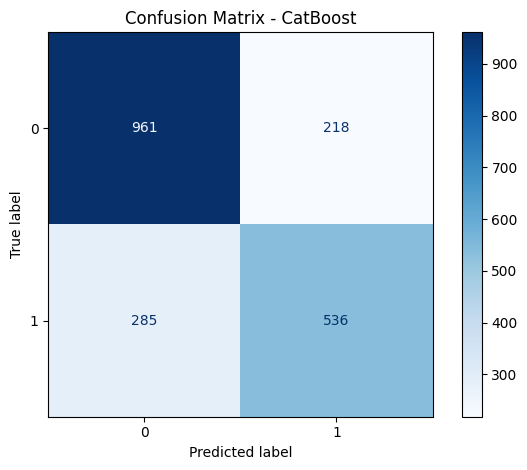

In [122]:
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_merged.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]


df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


class_counts = Counter(y_train)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}


model = CatBoostClassifier(
    verbose=False,
    # scale_pos_weight=1.44,
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=4,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=128,
    early_stopping_rounds=100,
    auto_class_weights='Balanced',
)


model.fit(
    X_train, y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test)
)


preds = model.predict(X_test)
print("\nClassification Report: ")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.tight_layout()
plt.show()





 Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80      1179
           1       0.71      0.67      0.69       821

    accuracy                           0.75      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.75      0.75      0.75      2000



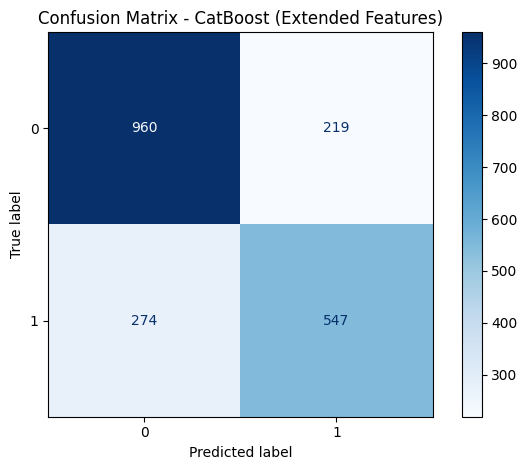

In [123]:
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"

categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]


df_fe = df_merged.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]
df_fe["phosphate_albumin_ratio"] = df_fe["Serum phosphate level"] / df_fe["Serum albumin level"]
df_fe["cholesterol_BMI_ratio"] = df_fe["Cholesterol level"] / df_fe["Body Mass Index (BMI)"]

df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])
df_fe["BMI_squared"] = df_fe["Body Mass Index (BMI)"] ** 2
df_fe["eGFR_squared"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] ** 2


df_fe["eGFR_IL6_interaction"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] * df_fe["Interleukin-6 (IL-6) level"]
df_fe["CRP_albumin_interaction"] = df_fe["C-reactive protein (CRP) level"] * df_fe["Serum albumin level"]

df_fe["is_eGFR_low"] = (df_fe["Estimated Glomerular Filtration Rate (eGFR)"] < 60).astype(int)
df_fe["is_CRP_elevated"] = (df_fe["C-reactive protein (CRP) level"] > 10).astype(int)


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


df_fe["mean_eGFR_by_age_bmi"] = df_fe.groupby(["Age_group", "BMI_category"])["Estimated Glomerular Filtration Rate (eGFR)"].transform("mean")


df_fe["urine_findings_sum"] = (
    df_fe["Pus cells in urine"].astype(str).map({"present": 1, "absent": 0, "missing": 0}) +
    df_fe["Sugar in urine"].astype(str).map({"present": 1, "absent": 0, "missing": 0}) +
    df_fe["Bacteria in urine"].astype(str).map({"present": 1, "absent": 0, "missing": 0})
)


for col in categorical_cols:
    df_fe[col] = df_fe[col].astype(str).fillna("Missing")


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


class_counts = Counter(y_train)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}

model = CatBoostClassifier(
    verbose=False,
    scale_pos_weight=1.44,
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=4,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=128,
    early_stopping_rounds=100
)

model.fit(
    X_train, y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test)
)


preds = model.predict(X_test)
print("\n Classification Report:\n", classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost (Extended Features)")
plt.tight_layout()
plt.show()


Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.97      0.73      1179
           1       0.35      0.02      0.04       821

    accuracy                           0.58      2000
   macro avg       0.47      0.50      0.39      2000
weighted avg       0.49      0.58      0.45      2000

Confusion Matrix:
 [[1149   30]
 [ 805   16]]


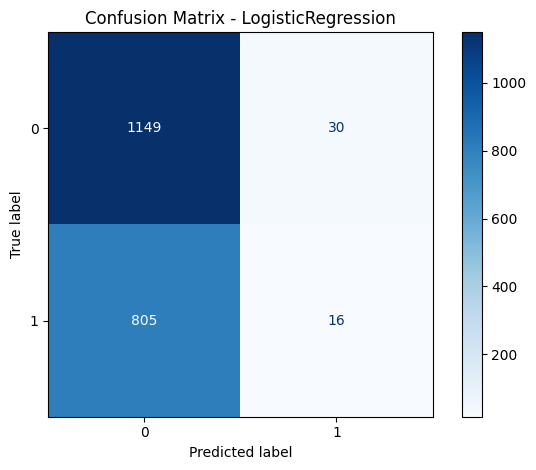

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


X = df_merged.drop('Target', axis=1)
y = df_merged['Target']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)


y_pred = logreg.predict(X_test)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - LogisticRegression")
plt.tight_layout()
plt.show()


Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.84      0.80      1179
           1       0.74      0.65      0.69       821

    accuracy                           0.76      2000
   macro avg       0.75      0.74      0.75      2000
weighted avg       0.76      0.76      0.76      2000



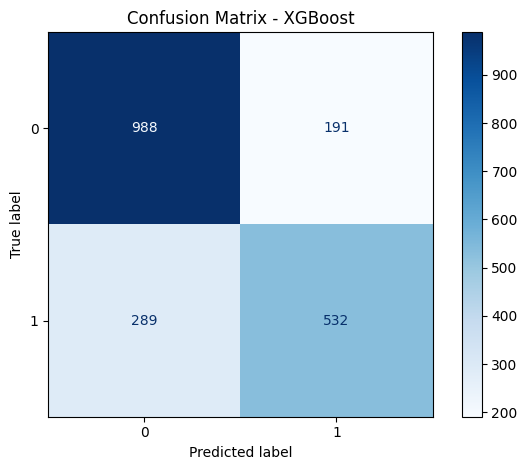

In [125]:
from collections import Counter
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_merged.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]


df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])


df_fe["IL6_CRP_interaction"] = df_fe["Interleukin-6 (IL-6) level"] * df_fe["C-reactive protein (CRP) level"]
df_fe["BMI_sodium_interaction"] = df_fe["Body Mass Index (BMI)"] * df_fe["Sodium level (mEq/L)"]
df_fe["BMI_squared"] = df_fe["Body Mass Index (BMI)"] ** 2
df_fe["eGFR_squared"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] ** 2


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]

for col in categorical_cols:
    df_fe[col] = df_fe[col].astype(str).fillna("missing")
    le = LabelEncoder()
    df_fe[col] = le.fit_transform(df_fe[col])


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


class_counts = Counter(y)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}
scale_pos_weight = weights[0] / weights[1] if 0 in weights and 1 in weights else 1


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=1.4,
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)


preds = xgb_model.predict(X_test)
print("\nClassification Report: ")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()


 Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.69      0.58      0.63      1179
           1       0.50      0.62      0.56       821

    accuracy                           0.59      2000
   macro avg       0.60      0.60      0.59      2000
weighted avg       0.61      0.59      0.60      2000



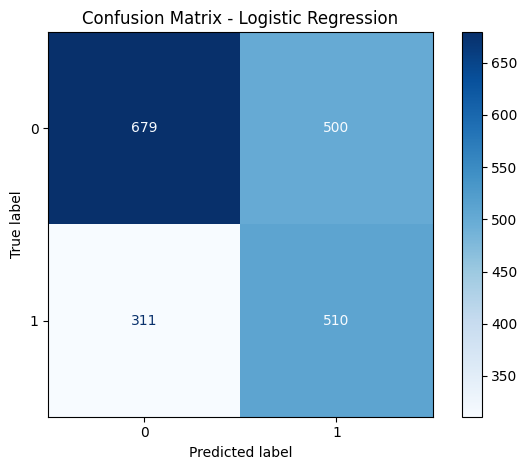


 Model: SVM
              precision    recall  f1-score   support

           0       0.77      0.83      0.80      1179
           1       0.73      0.64      0.68       821

    accuracy                           0.75      2000
   macro avg       0.75      0.73      0.74      2000
weighted avg       0.75      0.75      0.75      2000



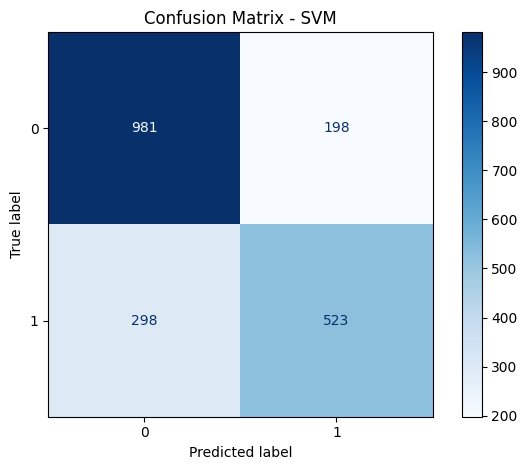


 Model: KNN
              precision    recall  f1-score   support

           0       0.61      0.38      0.47      1179
           1       0.42      0.65      0.51       821

    accuracy                           0.49      2000
   macro avg       0.52      0.52      0.49      2000
weighted avg       0.54      0.49      0.49      2000



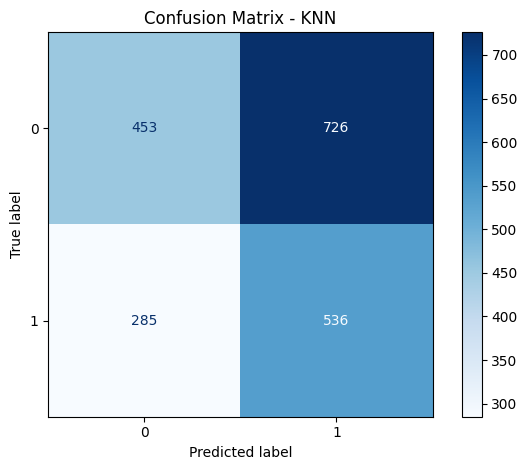


 Model: Random Forest
              precision    recall  f1-score   support

           0       0.67      0.96      0.79      1179
           1       0.86      0.33      0.47       821

    accuracy                           0.70      2000
   macro avg       0.76      0.64      0.63      2000
weighted avg       0.75      0.70      0.66      2000



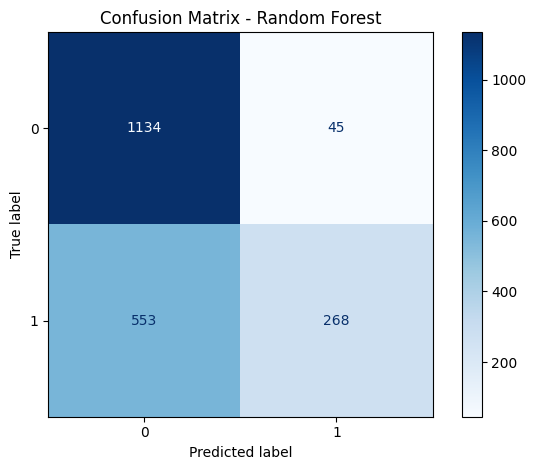


 Model: Decision Tree
              precision    recall  f1-score   support

           0       0.62      0.60      0.61      1179
           1       0.45      0.47      0.46       821

    accuracy                           0.55      2000
   macro avg       0.53      0.53      0.53      2000
weighted avg       0.55      0.55      0.55      2000



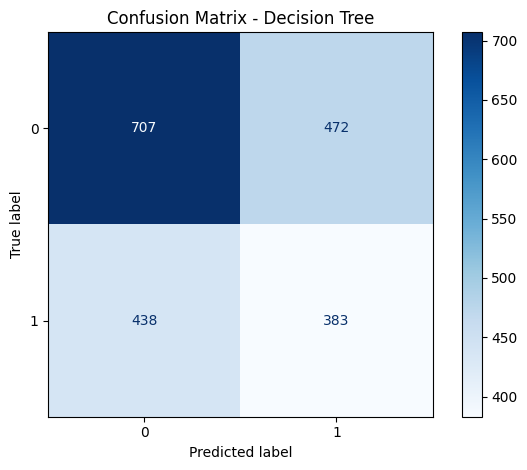


 Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.70      0.92      0.79      1179
           1       0.79      0.42      0.55       821

    accuracy                           0.72      2000
   macro avg       0.74      0.67      0.67      2000
weighted avg       0.73      0.72      0.69      2000



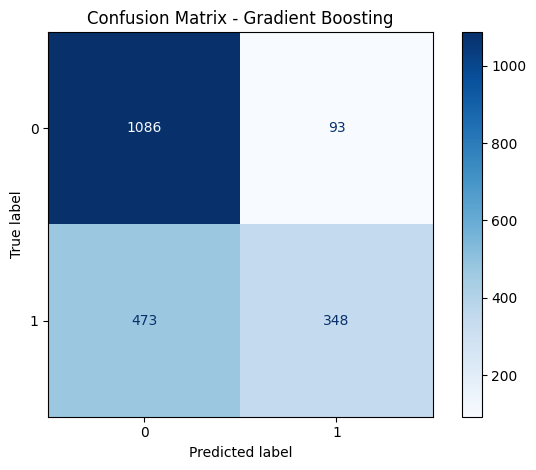


 Model: AdaBoost
              precision    recall  f1-score   support

           0       0.67      0.84      0.74      1179
           1       0.64      0.40      0.49       821

    accuracy                           0.66      2000
   macro avg       0.65      0.62      0.62      2000
weighted avg       0.66      0.66      0.64      2000



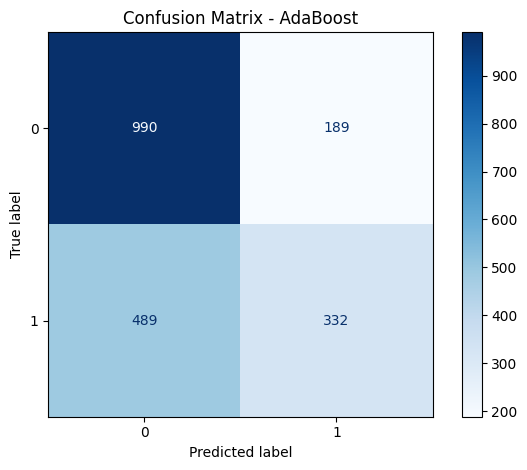


 Model: Naive Bayes
              precision    recall  f1-score   support

           0       0.74      0.83      0.78      1179
           1       0.71      0.58      0.64       821

    accuracy                           0.73      2000
   macro avg       0.72      0.71      0.71      2000
weighted avg       0.73      0.73      0.72      2000



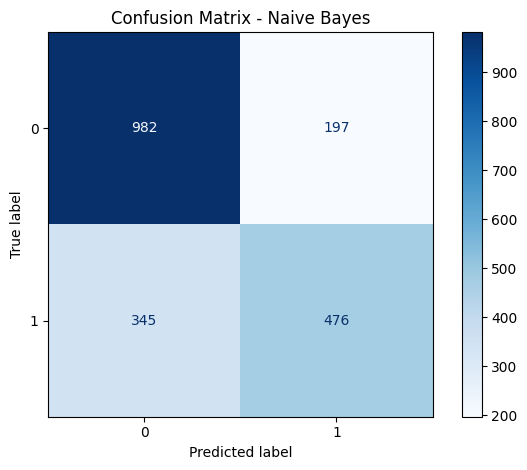


 Model: MLP (ANN)
              precision    recall  f1-score   support

           0       0.69      0.70      0.70      1179
           1       0.56      0.54      0.55       821

    accuracy                           0.64      2000
   macro avg       0.62      0.62      0.62      2000
weighted avg       0.64      0.64      0.64      2000



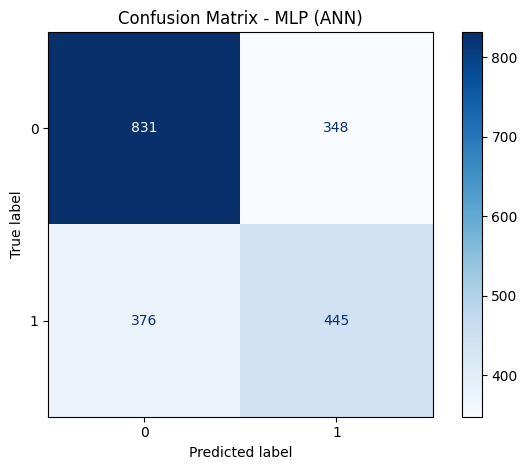

In [126]:
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_merged.copy()

df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]
df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])
df_fe["IL6_CRP_interaction"] = df_fe["Interleukin-6 (IL-6) level"] * df_fe["C-reactive protein (CRP) level"]
df_fe["BMI_sodium_interaction"] = df_fe["Body Mass Index (BMI)"] * df_fe["Sodium level (mEq/L)"]
df_fe["BMI_squared"] = df_fe["Body Mass Index (BMI)"] ** 2
df_fe["eGFR_squared"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] ** 2
df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])

appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)

for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]

for col in categorical_cols:
    df_fe[col] = df_fe[col].astype(str).fillna("missing")
    le = LabelEncoder()
    df_fe[col] = le.fit_transform(df_fe[col])


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


scaler = MinMaxScaler()
X[X.columns] = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
    "MLP (ANN)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
}


for name, model in models.items():
    print(f"\n Model: {name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

In [127]:
df_merged.shape


(10000, 43)